<a href="https://colab.research.google.com/github/Varshini-Anand/Nunnariacademy_Datasciencewithaibootcamp/blob/main/Nunnari_Academy_DS_with_AI_bootcamp_Day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**House Price Prediction**

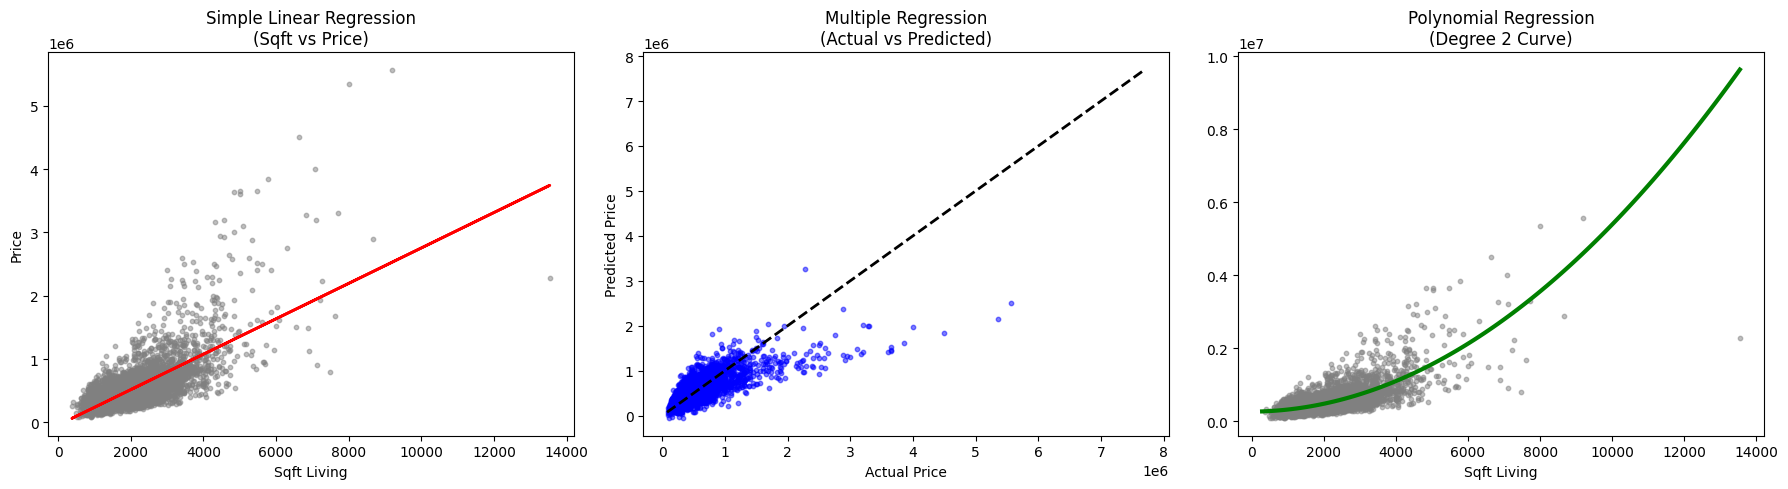

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
url = "/content/sample_data/houseprice.csv"
df = pd.read_csv(url)

# Use a subset for clearer visualization
X = df[['sqft_living']].values
X_multi = df[['sqft_living', 'bedrooms', 'bathrooms', 'grade']].values
y = df['price'].values

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
_, X_test_m, _, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Create a figure for plotting
plt.figure(figsize=(18, 5))

# --- 1. Simple Linear Regression Plot ---
plt.subplot(1, 3, 1)
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
plt.scatter(X_test, y_test, color='gray', alpha=0.5, s=10)
plt.plot(X_test, model_simple.predict(X_test), color='red', linewidth=2)
plt.title("Simple Linear Regression\n(Sqft vs Price)")
plt.xlabel("Sqft Living")
plt.ylabel("Price")

# --- 2. Multiple Regression Plot (Actual vs Predicted) ---
# Since we can't plot 4D space, we plot how close predictions are to reality
plt.subplot(1, 3, 2)
model_multi = LinearRegression()
model_multi.fit(X_multi, y) # Training on subset for demo
y_pred_multi = model_multi.predict(X_test_m)
plt.scatter(y_test_m, y_pred_multi, color='blue', alpha=0.5, s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Diagonal line
plt.title("Multiple Regression\n(Actual vs Predicted)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# --- 3. Polynomial Regression Plot ---
plt.subplot(1, 3, 3)
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# Sort values for a smooth curve line
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_poly_pred = model_poly.predict(X_range_poly)

plt.scatter(X_test, y_test, color='gray', alpha=0.5, s=10)
plt.plot(X_range, y_poly_pred, color='green', linewidth=3)
plt.title("Polynomial Regression\n(Degree 2 Curve)")
plt.xlabel("Sqft Living")

plt.tight_layout()
plt.show()